# Pagoda2.1 Multiome Workflow (RNA + ATAC)

pagoda2.1 represents a multi-modal dataset as a set of **facets** — one
per molecular modality measured in the same cells. A facet bundles its
modality’s raw counts, the normalization *view recipe* suited to that
modality, and its reductions; all facets share the same cells. Loading a
plain count matrix creates a single **default facet** named `RNA` (so
ordinary scRNA-seq needs no facet arguments — see the [single-dataset
notebook](pagoda2.1-single-dataset.ipynb)); extra modalities become
extra facets, and the analysis verbs take `facet =` (one modality) or
`facets =` (integrate across them).

This notebook uses a 10x
[multiome](https://www.10xgenomics.com/datasets/pbmc-from-a-healthy-donor-granulocytes-removed-through-cell-sorting-3-k-1-standard-2-0-0)
sample (PBMC, granulocyte-sorted 3k): each cell is measured by both gene
expression (RNA) and chromatin accessibility (ATAC peaks). The two
modalities need different treatment — RNA is reduced by PCA, ATAC by LSI
— and are then integrated with **weighted nearest neighbors (WNN)**. The
pattern is the same as the [CITE-seq notebook](pagoda2.1-citeseq.ipynb);
only the per-facet reductions differ. The 10x file is in a local folder
named `data`.

## Import: one object, two facets

A multiome 10x HDF5 carries both `Gene Expression` and `Peaks` feature
types; pagoda2 reads the per-feature `feature_type` and builds an `RNA`
and an `ATAC` facet automatically, each with the right view model. RNA
uses `plain` (library-size normalize, then `log1p`). ATAC uses `tfidf`
(term-frequency × inverse-document-frequency): accessibility is
near-binary and there are tens of thousands of peaks, so TF-IDF
down-weights ubiquitous, uninformative peaks and up-weights
cell-type-specific ones.

In [ ]:
p2 <- pagoda2::Pagoda2$from10xH5("data/pbmc_granulocyte_sorted_3k_filtered_feature_bc_matrix.h5", verbose = FALSE)
sapply(p2$listFacets(), function(f) p2$getFacet(f)$modelType)   # facet -> view model

    RNA    ATAC 
"plain" "tfidf" 

`RNA` is the default facet (steps without a `facet=` act on it); `ATAC`
adds tens of thousands of peaks over the same cells.

## QC

In [ ]:
p2$runQC(verbose = FALSE)

## Reduce each modality on its own terms

The pipeline verbs are generic — the algorithm is a `method=`. For RNA
we run PCA on the overdispersed genes. For ATAC we run **LSI** (latent
semantic indexing): SVD of the TF-IDF view, dropping the first
component, which tracks sequencing depth rather than biology. LSI is to
ATAC what PCA is to RNA. Here we run LSI on the most-accessible peaks
for speed; drop the `genes =` subset for a full analysis. Scores are
name-keyed: `reductions[["PCA"]]` for RNA, `reductions[["ATAC:LSI"]]`
for ATAC.

In [ ]:
p2$runVariance(verbose = FALSE)
p2$runReduction(nPcs = 30, verbose = FALSE)
top.peaks <- names(sort(Matrix::colSums(p2$getFacet("ATAC")$rawCounts), decreasing = TRUE))[1:20000]
p2$runReduction(facet = "ATAC", method = "lsi", genes = top.peaks, nPcs = 30, verbose = FALSE)
names(p2$reductions)

[1] "PCA"      "ATAC:LSI"

## Integrate the modalities with WNN

**WNN** (weighted nearest neighbors; Hao et al., *Cell* 2021) learns,
for each cell, how informative each modality’s neighborhood is about
that cell, turns it into a **per-cell weight per modality**, and fuses
the per-modality neighbor graphs accordingly — local weighting, not a
single global ratio. `runGraph(method = "wnn")` stores the per-cell
weights (`cellMeta$wnn_weight_RNA`, `..._ATAC`), the fused graph
(`graphs[["WNN"]]`), and a joint reduction (`reductions[["WNN"]]`); we
then cluster on the fused graph with Leiden.

In [ ]:
p2$runGraph(method = "wnn", facets = c("RNA", "ATAC"), verbose = FALSE)
p2$runClustering(graph = "WNN", name = "wnn_leiden")

## What each modality resolves

To see what integration buys, embed each facet’s own reduction and the
joint WNN reduction, and color all three by the **same** joint clusters.
Where a panel mixes cluster colors, that modality alone cannot separate
those cells; the WNN panel shows the combined resolution.

In [ ]:
p2$runEmbedding(reduction = "PCA", name = "umap", verbose = FALSE)        # RNA alone
p2$runEmbedding(reduction = "ATAC:LSI", name = "umap", verbose = FALSE)   # ATAC alone
p2$runEmbedding(reduction = "WNN", name = "umap", verbose = FALSE)        # joint

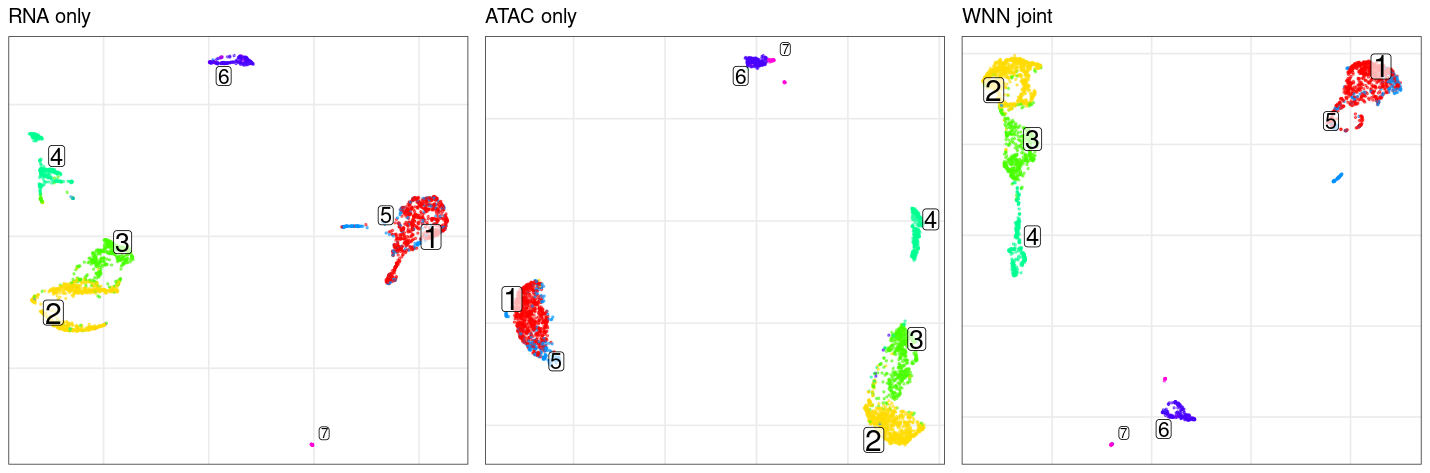

In [ ]:
g_rna <- p2$plotEmbedding(reduction = "PCA", embedding = "umap", grouping = "wnn_leiden", mark.groups = TRUE, size = 0.4, alpha = 0.5, title = "RNA only")
g_atac <- p2$plotEmbedding(reduction = "ATAC:LSI", embedding = "umap", grouping = "wnn_leiden", mark.groups = TRUE, size = 0.4, alpha = 0.5, title = "ATAC only")
g_wnn <- p2$plotEmbedding(reduction = "WNN", embedding = "umap", grouping = "wnn_leiden", mark.groups = TRUE, size = 0.4, alpha = 0.5, title = "WNN joint")
cowplot::plot_grid(g_rna, g_atac, g_wnn, nrow = 1)

The per-cell ATAC weight maps where chromatin accessibility, rather than
RNA, was the more informative modality:

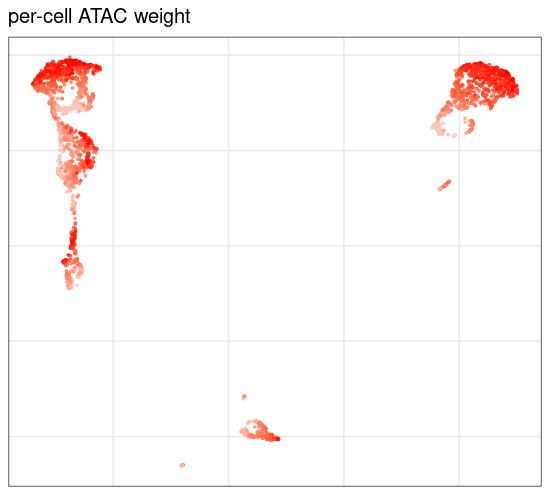

In [ ]:
p2$plotEmbedding(reduction = "WNN", embedding = "umap",
                 colors = stats::setNames(p2$cellMeta$wnn_weight_ATAC, rownames(p2$cellMeta)),
                 size = 0.5, alpha = 0.7, title = "per-cell ATAC weight")

## Markers

Genes are the interpretable modality, so we call markers on the RNA
facet for the joint clusters (ATAC contributes accessibility structure
to the integration, but cluster identity is read from gene expression).
The dot plot shows the top markers per cluster — color is mean
expression, dot size the fraction of cells expressing.

In [ ]:
p2$runMarkers(grouping = "wnn_leiden", name = "wnn_markers", verbose = FALSE)

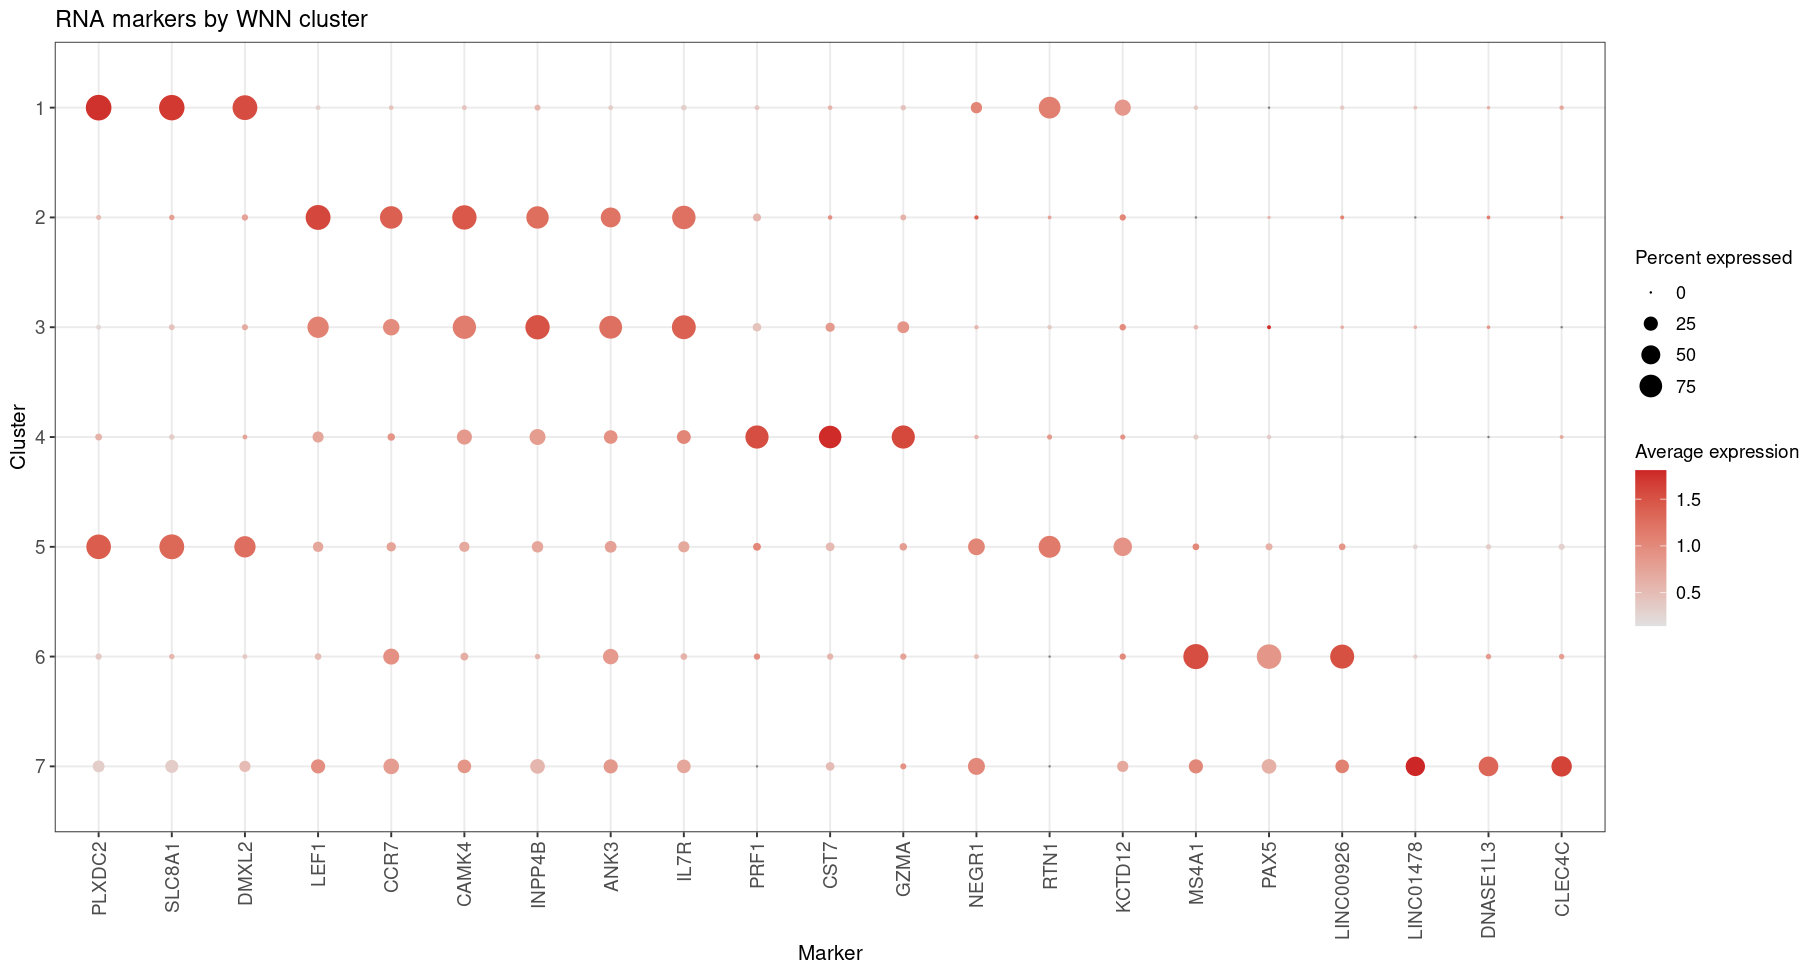

In [ ]:
p2$plotMarkerDotPlot(markers = "wnn_markers", n.genes.per.group = 3, selection = "balanced",
                     order.groups = TRUE, dot.scale = 6) +
  ggplot2::labs(title = "RNA markers by WNN cluster") +
  ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 90, hjust = 1, vjust = 0.5))

Canonical lineage genes on the joint embedding confirm the clusters —
`plotEmbedding(gene = ...)` colors by a gene’s expression (the default
RNA facet here):

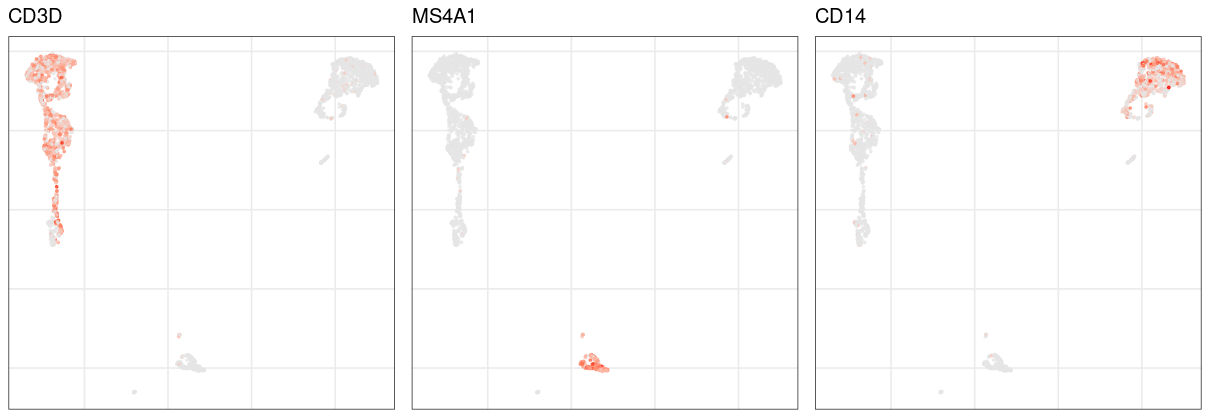

In [ ]:
genes <- intersect(c("CD3D", "MS4A1", "CD14"), colnames(p2$getRawCounts()))   # T / B / monocyte
plots <- lapply(genes, function(g)
  p2$plotEmbedding(reduction = "WNN", embedding = "umap", gene = g, size = 0.5, alpha = 0.7, title = g))
cowplot::plot_grid(plotlist = plots, nrow = 1)

## Next steps

Annotate the WNN clusters from the RNA markers
(`p2$annotateClusters(from = "wnn_leiden", ...)`). Reduction-level
integration is also available
(`p2$runReduction(facets = c("RNA","ATAC"), method = "cca")`), and a
disk-backed `backend = "lstar"` facet keeps the large peak matrix out of
memory for atlas-scale data. See the
[single-dataset](pagoda2.1-single-dataset.ipynb) (RNA) and
[CITE-seq](pagoda2.1-citeseq.ipynb) (RNA + protein) notebooks for the
other modalities.